### Importing

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Cement_slump.csv")
df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


### EDA

In [58]:
df.shape

(103, 10)

In [59]:
df.columns = ["Cement" , "Slag" , "Fly_ash" , "Water" , "SP" , "Coarse_aggr" , "Fine_aggr" , "Slump" , "Flow" , "Compressive_strength"]

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.isnull().sum()

Cement                  0
Slag                    0
Fly_ash                 0
Water                   0
SP                      0
Coarse_aggr             0
Fine_aggr               0
Slump                   0
Flow                    0
Compressive_strength    0
dtype: int64

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cement                103 non-null    float64
 1   Slag                  103 non-null    float64
 2   Fly_ash               103 non-null    float64
 3   Water                 103 non-null    float64
 4   SP                    103 non-null    float64
 5   Coarse_aggr           103 non-null    float64
 6   Fine_aggr             103 non-null    float64
 7   Slump                 103 non-null    float64
 8   Flow                  103 non-null    float64
 9   Compressive_strength  103 non-null    float64
dtypes: float64(10)
memory usage: 8.2 KB


In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,103.0,229.894175,78.877230,137.00,152.00,248.00,303.900,374.00
Slag,103.0,77.973786,60.461363,0.00,0.05,100.00,125.000,193.00
Fly_ash,103.0,149.014563,85.418080,0.00,115.50,164.00,235.950,260.00
Water,103.0,197.167961,20.208158,160.00,180.00,196.00,209.500,240.00
SP,103.0,8.539806,2.807530,4.40,6.00,8.00,10.000,19.00
Coarse_aggr,103.0,883.978641,88.391393,708.00,819.50,879.00,952.800,1049.90
Fine_aggr,103.0,739.604854,63.342117,640.60,684.50,742.70,788.000,902.00
Slump,103.0,18.048544,8.750844,0.00,14.50,21.50,24.000,29.00
Flow,103.0,49.610680,17.568610,20.00,38.50,54.00,63.750,78.00
Compressive_strength,103.0,36.038738,7.837120,17.19,30.90,35.52,41.205,58.53


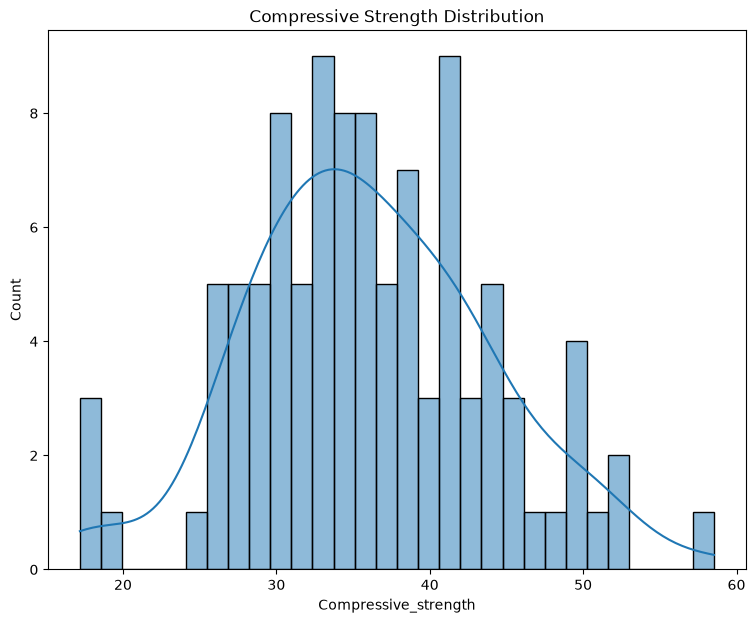

In [64]:
plt.figure(figsize = (9 , 7))
sns.histplot(df["Compressive_strength"] , bins = 30 , kde = True)

plt.title("Compressive Strength Distribution")
plt.xlabel("Compressive_strength")
plt.ylabel("Count")
plt.show()

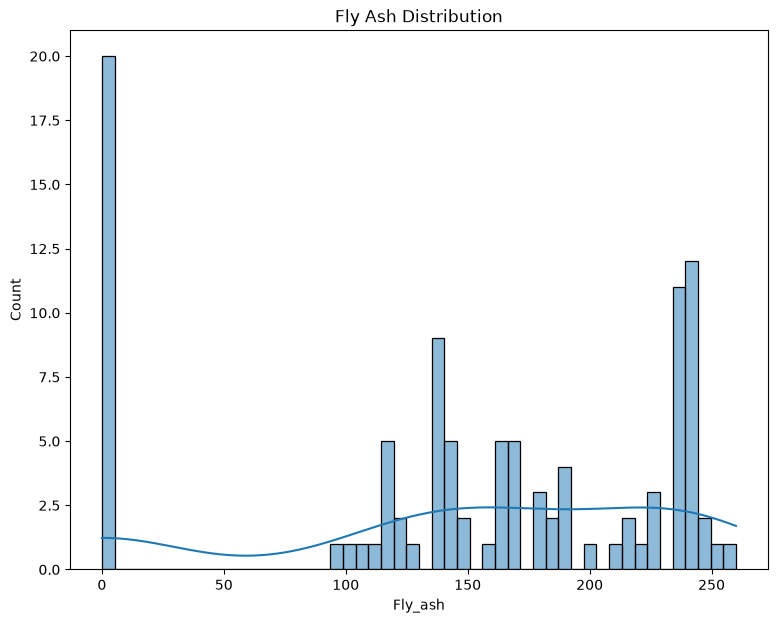

In [65]:
plt.figure(figsize = (9 , 7))
sns.histplot(df["Fly_ash"] , bins = 50 , kde = True)

plt.title("Fly Ash Distribution")
plt.xlabel("Fly_ash")
plt.ylabel("Count")
plt.show()

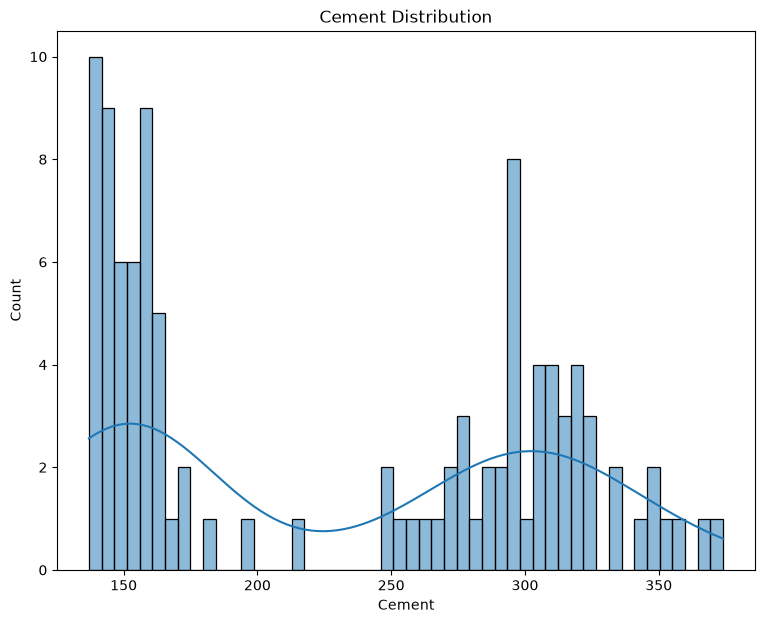

In [66]:
plt.figure(figsize = (9 , 7))
sns.histplot(df["Cement"] , bins = 50 , kde = True)

plt.title("Cement Distribution")
plt.xlabel("Cement")
plt.ylabel("Count")
plt.show()

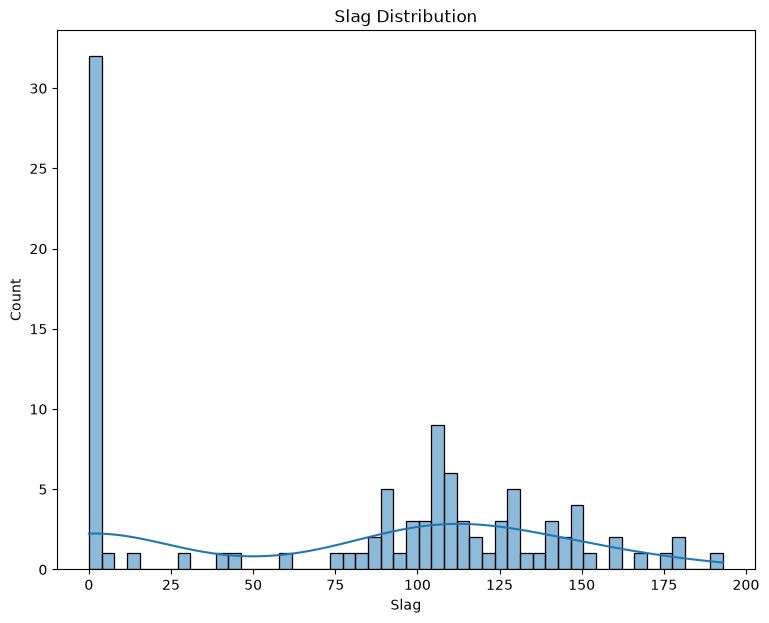

In [67]:
plt.figure(figsize = (9 , 7))
sns.histplot(df["Slag"] , bins = 50 , kde = True)

plt.title("Slag Distribution")
plt.xlabel("Slag")
plt.ylabel("Count")
plt.show()

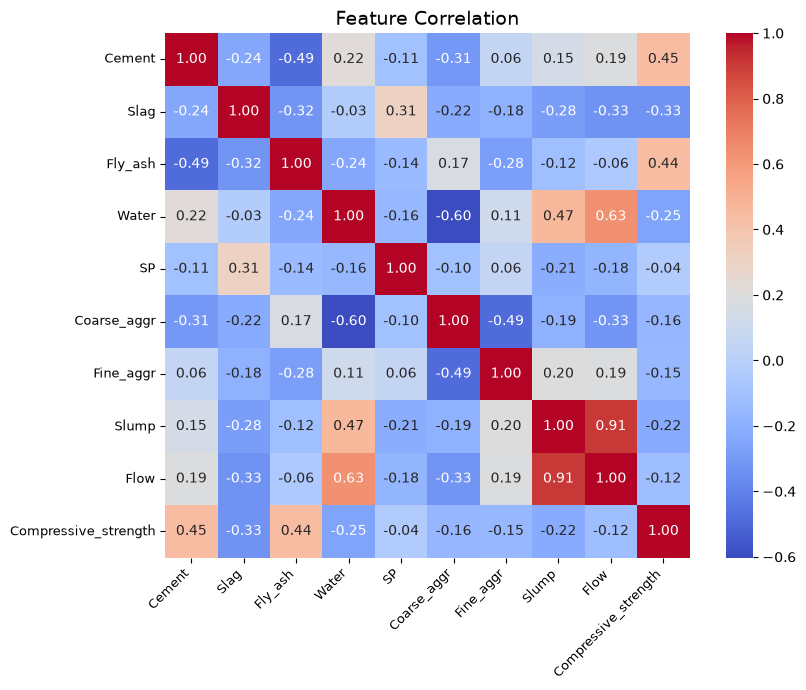

In [68]:
plt.figure(figsize = (9 , 7))
sns.heatmap(df.corr() , annot = True , cmap = "coolwarm" , square = True , fmt = ".2f")

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

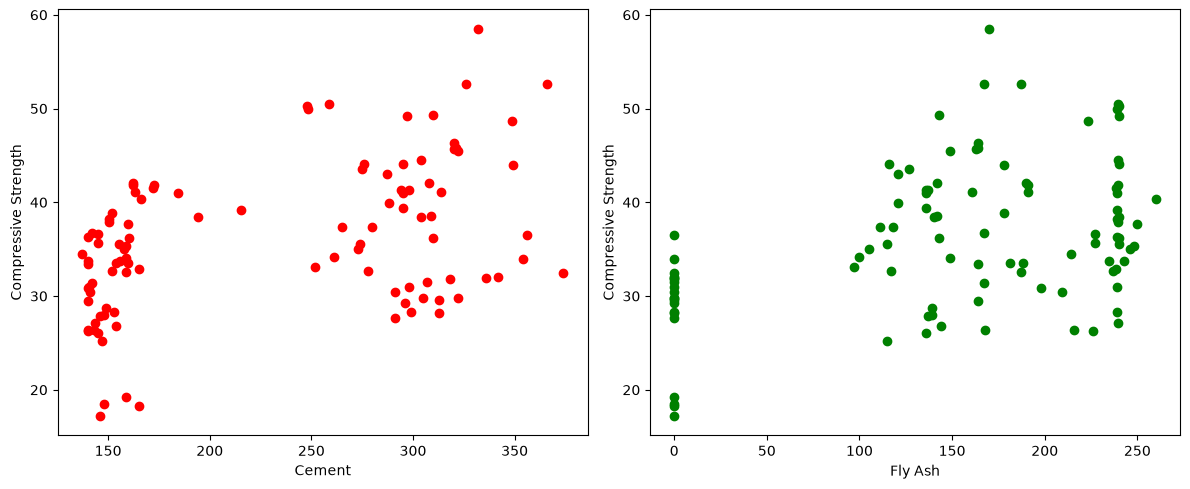

In [69]:
fig , axes = plt.subplots(nrows = 1 , ncols = 2 , figsize = (12 , 5))

axes[0].scatter(df["Cement"] , df["Compressive_strength"] , color = "red")
axes[0].set_xlabel("Cement")
axes[0].set_ylabel("Compressive Strength")

axes[1].scatter(df["Fly_ash"] , df["Compressive_strength"] , color = "green")
axes[1].set_xlabel("Fly Ash")
axes[1].set_ylabel("Compressive Strength")

plt.tight_layout()

### Feature & Target Split

In [70]:
X = df.drop(columns = ["Compressive_strength"])
y = df["Compressive_strength"]

### Train & Test Split

In [71]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 18 , random_state = 101)

### Making Pipeline

In [72]:
scaler = StandardScaler()
model = SVR()

In [73]:
pipe = Pipeline([("scaler" , scaler) , ("model" , model)])

### GridSearchCV & Model Training

In [74]:
param_grid = {
    "model__kernel" : ["linear" , "rbf" , "poly"] ,
    "model__C" : [0.001 , 0.01 , 0.1 , 0.5 , 1.0 , 10.0] , 
    "model__gamma" : ["scale" , "auto"] , 
    "model__degree" : [2 , 3 , 4] ,
    "model__epsilon" : [0 , 0.01 , 0.1 , 0.5 , 1 , 2]
}

In [76]:
grid_model = GridSearchCV(estimator = pipe , param_grid = param_grid , scoring = "neg_mean_squared_error" , cv = 5)
grid_model.fit(X_train , y_train)
grid_model.best_params_

{'model__C': 10.0,
 'model__degree': 2,
 'model__epsilon': 2,
 'model__gamma': 'scale',
 'model__kernel': 'linear'}

### Prediction

In [77]:
y_pred = grid_model.predict(X_test)

### Evaluation

In [78]:
print("Final Model : Support Vector Regressor")
print(f"MAE : {mean_absolute_error(y_test , y_pred)}")
print(f"MSE : {mean_squared_error(y_test , y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test , y_pred)}")
print(f"R2 Score : {r2_score(y_test , y_pred)}")

Final Model : Support Vector Regressor
MAE : 1.6929768201506137
MSE : 4.789041145296427
RMSE : 2.188387795911965
R2 Score : 0.9328500831868648


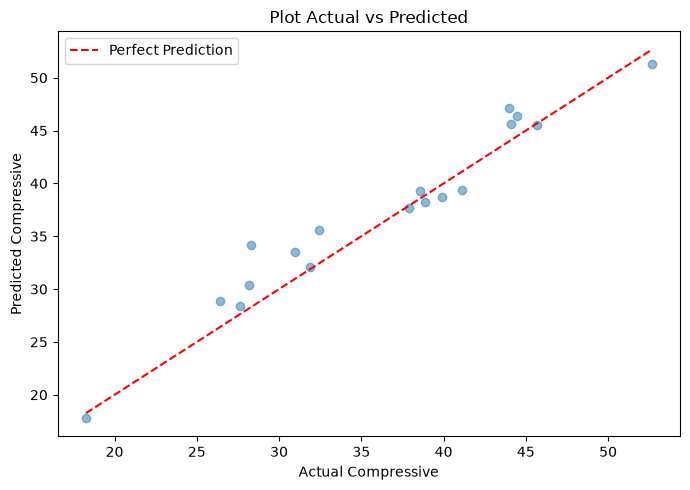

In [79]:
plt.figure(figsize = (7 , 5))
plt.scatter(y_test , y_pred , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , linestyle = "--" , label = "Perfect Prediction")

plt.title("Plot Actual vs Predicted")
plt.xlabel("Actual Compressive")
plt.ylabel("Predicted Compressive")
plt.tight_layout()
plt.legend()
plt.show()

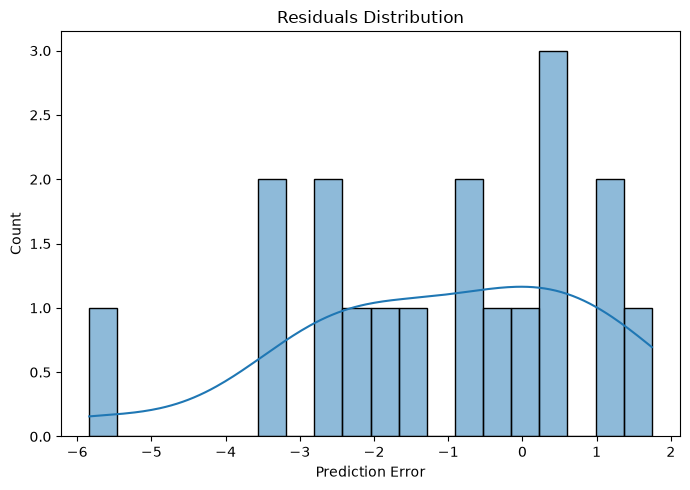

In [81]:
residuals = y_test - y_pred

plt.figure(figsize = (7 , 5))
sns.histplot(residuals , bins = 20 , kde = True)

plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()